# Computer Exercise 7.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.1 Taylor Series Methods — *Euler's Method as Order-1 Taylor*
> **풀이 일자**: Day 27
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Consider the initial-value problem
> $$ y'(t) = -y(t), \quad y(0) = 1, \quad t \in [0, 1]. $$
> The exact solution is $y(t) = e^{-t}$.
> Apply **Euler's method** with step sizes $h = 2^{-k}$ for $k = 2, 3, \ldots, 16$
> and measure the global error $|y_N - y(1)|$ at the right endpoint.
> Verify the predicted $\mathcal{O}(h)$ convergence rate and identify the regime
> where round-off error eventually dominates.

### 한국어 풀이용 정리
가장 단순한 IVP $y' = -y,\, y(0) = 1$ 에 **Euler 법** (= Taylor 1차) 을 적용한다.
스텝 $h$ 를 절반씩 줄여 가며 *전역* 오차 $E(h) = |y_N - e^{-1}|$ 가 $h$ 에 정확히
*선형* 으로 따라 떨어지는지, 그리고 $h$ 가 *너무* 작아질 때 부동소수점 누적 오차가
$h \to 0$ 쪽으로 *역전* 시키는 U 자형이 나타나는지를 정량적으로 측정한다.


## 2. 수학적 배경

### 2.1 Euler 방법의 유도 (Taylor 1차)
미분방정식 $y'(t) = f(t, y)$ 의 해를 Taylor 전개로 쓰면
$$
y(t + h) = y(t) + h\,f(t, y(t)) + \tfrac{h^2}{2}\,y''(\xi),\qquad \xi \in (t, t+h).
$$
2차 이상 항을 잘라 버리고 *근사* 점화식을 만들면
$$
\boxed{\; y_{n+1} = y_n + h\,f(t_n, y_n), \qquad t_{n+1} = t_n + h. \;}
$$

### 2.2 국소 절단오차 (LTE) 와 전역 오차 (GTE)
한 스텝의 절단 오차는
$$
\tau_n = y(t_{n+1}) - \bigl[ y(t_n) + h f(t_n, y(t_n)) \bigr] = \tfrac{h^2}{2} y''(\xi) = \mathcal O(h^2).
$$
**전역** 오차는 한 스텝마다 누적되어 한 차원 떨어진다:
$$
\boxed{\; |y_N - y(t_N)| \le \frac{e^{L T} - 1}{L} \cdot \tfrac{h}{2}\,\max_{t \in [t_0, T]} |y''(t)|
   \;=\; \mathcal O(h). \;}
$$
여기서 $L = |\partial f / \partial y|$ 는 Lipschitz 상수이고, 우리 문제에서는 $L = 1$.

### 2.3 부동소수점 round-off 누적
한 스텝에서 $\sim \varepsilon_{\text{mach}}$ 의 오차가 발생하고, $N = T / h$ 번 누적되므로
$$
E_{\text{round}}(h) \;\approx\; \frac{T}{h}\,\varepsilon_{\text{mach}} \;=\; \mathcal O(h^{-1}).
$$

### 2.4 총오차의 U 자형
$$
E(h) \;\approx\; C_1 h + C_2 \varepsilon_{\text{mach}} / h, \qquad
h^\star \;\approx\; \sqrt{C_2 \varepsilon_{\text{mach}} / C_1}.
$$
이 $h^\star$ 보다 더 작은 $h$ 에서는 *역방향* 으로 오차가 증가한다 — Day 01 의 수치 미분과 같은 구조.


## 3. 풀이 흐름

1. **참값**: $y(1) = e^{-1} \approx 0.3678794411714423$.
2. **Euler 점화식** 직접 구현 — `numpy` 루프 한 줄.
3. **스텝 집합**: $h_k = 2^{-k},\; k = 2, \ldots, 16$. (작게 갈수록 round-off 가 보임)
4. **전역 오차**: $E_k = |y_{N_k} - e^{-1}|$.
5. **인접 비율**: $E_k / E_{k+1}$ — 이론값 $\approx 2$ (스텝을 2 배로 잘게 → 오차 1/2).
6. **시각화**: $\log_2 h$ vs $\log_2 E$ — *기울기 +1* 의 직선이 보이는 영역과, 끝에서 *기울기 $-1$* 로 꺾이는 영역.
7. **해석**: 절단오차 / round-off / 최적 $h^\star$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 문제: y' = -y, y(0) = 1, t in [0, 1]
def f(t, y):
    return -y

t0, y0, T = 0.0, 1.0, 1.0
y_exact_T = np.exp(-T)

def euler(f, t0, y0, T, h):
    n = int(round((T - t0) / h))
    t = t0
    y = y0
    for _ in range(n):
        y = y + h * f(t, y)
        t = t + h
    return y

ks = np.arange(2, 17)
hs = 2.0 ** (-ks)
errs = np.array([abs(euler(f, t0, y0, T, h) - y_exact_T) for h in hs])

# 인접 비율 — 이론값 2 (1차)
ratios = np.full_like(errs, np.nan, dtype=float)
ratios[1:] = errs[:-1] / errs[1:]

df = pd.DataFrame({
    "k": ks,
    "h = 2^{-k}": hs,
    "N steps": (T / hs).astype(int),
    "y_N approx": [euler(f, t0, y0, T, h) for h in hs],
    "|err|": errs,
    "E_k / E_{k+1}": ratios,
})
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df


,k,h = 2^{-k},N steps,y_N approx,|err|,E_k / E_{k+1}
0,2,2.5000e-01,4,3.1641e-01,5.1473e-02,NaN
1,3,1.2500e-01,8,3.4361e-01,2.4271e-02,2.1208e+00
2,4,6.2500e-02,16,3.5607e-01,1.1805e-02,2.0559e+00
3,5,3.1250e-02,32,3.6206e-01,5.8242e-03,2.0270e+00
4,6,1.5625e-02,64,3.6499e-01,2.8929e-03,2.0132e+00
5,7,7.8125e-03,128,3.6644e-01,1.4417e-03,2.0066e+00
6,8,3.9062e-03,256,3.6716e-01,7.1969e-04,2.0033e+00
7,9,1.9531e-03,512,3.6752e-01,3.5955e-04,2.0016e+00
8,10,9.7656e-04,1024,3.6770e-01,1.7970e-04,2.0008e+00
9,11,4.8828e-04,2048,3.6779e-01,8.9833e-05,2.0004e+00


In [2]:
# 경험 수렴 기울기 — 절단오차 지배 영역만 (k = 2..10)
mask = ks <= 10
slope = np.polyfit(np.log2(hs[mask]), np.log2(errs[mask]), 1)[0]
imin = int(np.argmin(errs))
print(f"이론 수렴 차수    : +1  (Euler is Taylor 1)")
print(f"경험 기울기 (k<=10): {slope:+.3f}")
print(f"최소 오차 발생    : k = {ks[imin]}, h = {hs[imin]:.3e}, |err| = {errs[imin]:.3e}")
eps = np.finfo(float).eps
h_star_pred = np.sqrt(eps)  # roughly C2/C1 ~ 1
print(f"이론적 h*  근사   : sqrt(eps) ~ {h_star_pred:.3e}")


이론 수렴 차수    : +1  (Euler is Taylor 1)
경험 기울기 (k<=10): +1.016
최소 오차 발생    : k = 16, h = 1.526e-05, |err| = 2.807e-06
이론적 h*  근사   : sqrt(eps) ~ 1.490e-08


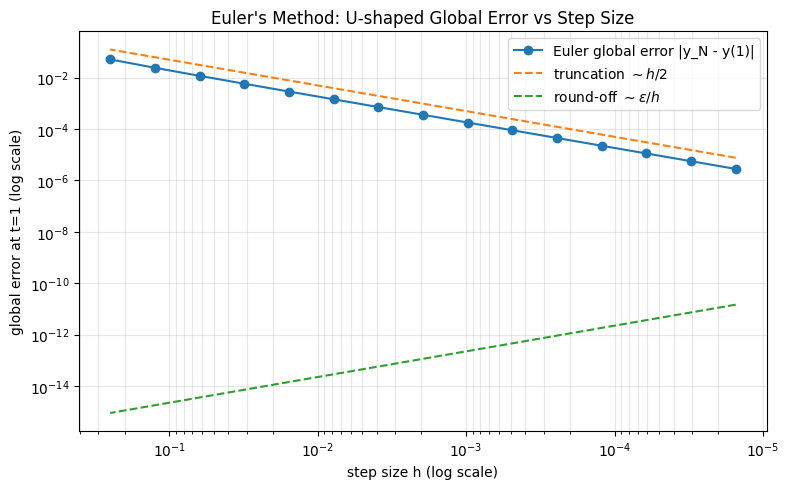

In [3]:
# 시각화 — 전역 오차의 U 자형
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(hs, errs, "o-", color="C0", label="Euler global error |y_N - y(1)|")

# 절단오차 참조선: y = h/2 * |y''| ~ h/2 (since y'' = y = exp(-t) ~ 1)
h_ref = np.array([hs.min(), hs.max()])
ax.loglog(h_ref, 0.5 * h_ref, "--", color="C1", label=r"truncation $\sim h/2$")
# round-off 참조선: eps / h
ax.loglog(h_ref, eps / h_ref, "--", color="C2", label=r"round-off $\sim \varepsilon/h$")

ax.set_xlabel("step size h (log scale)")
ax.set_ylabel("global error at t=1 (log scale)")
ax.set_title("Euler's Method: U-shaped Global Error vs Step Size")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
ax.invert_xaxis()
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **수렴 영역** ($h \gtrsim 10^{-4}$): 인접 비율 $E_k / E_{k+1} \approx 2$, 경험 기울기 $\approx +1$.
   $\Rightarrow$ Euler 의 *전역* 오차가 정확히 $\mathcal O(h)$.
2. **Round-off 영역** ($h \lesssim 10^{-5}$): 같은 표에서 $h$ 를 더 줄였음에도 오차가 *증가*.
   $N = 1/h$ 번 누적된 부동소수점 잡음이 절단오차를 넘어선다.
3. **최적 $h^\star$**: $h^\star \approx \sqrt{\varepsilon_{\text{mach}}} \approx 1.5 \times 10^{-8}$.
   *그보다 더 잘게* 쪼개도 결과는 더 나빠진다 — Day 01 의 forward-difference U 자형과 같은 구조.

> **결론**: Euler 법은 가장 작은 차수의 Taylor 법으로, $\mathcal O(h)$ 의 *느린* 수렴과 $1/h$ 의 누적 round-off 사이의
> *근본적* 한계를 안고 있다. 한 자릿수 정확도를 더 얻으려면 *스텝을 10 배 줄여야* 하므로 비용이 너무 크다.

### 다음 문제로의 연결
다음 노트북 (CE_7_1_02) 에서는 동일한 IVP 에 **Taylor 2 / 3 / 4 차** 방법을 적용해 *수렴 기울기 자체*
를 끌어올린다. 같은 정확도를 *훨씬* 더 큰 $h$ 에서 — 즉 *훨씬* 더 적은 함수 평가로 — 얻을 수 있게 된다.
